# **Day 40: Cross-Validation Strategies**
*Module 6 - Ensemble Learning*

Cross-validation (CV) estimates how a model will perform on **new data from the same population**. The key word is **"new"**: our CV splits must mimic how the model will be used. A random K-fold split is correct only if samples are independent. Grouped, temporal and spatial data need special splits, or the estimate is wildly optimistic.

> Cross-validation splits the data several times into training and validation parts, so every sample is used for testing once. The split must match the data structure: stratified for imbalanced classes, grouped for repeated measures, blocked for time or space.
>
> *Example:* Pixels from the same field are near-duplicates. If some go to training and some to testing, the score is inflated, so whole fields must stay together (GroupKFold).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import (KFold, StratifiedKFold, RepeatedKFold, LeaveOneOut, GroupKFold, StratifiedGroupKFold,
                                     TimeSeriesSplit, ShuffleSplit, cross_val_score, GridSearchCV)
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
rng = np.random.default_rng(40)

## **1. Visualising Split Strategies**

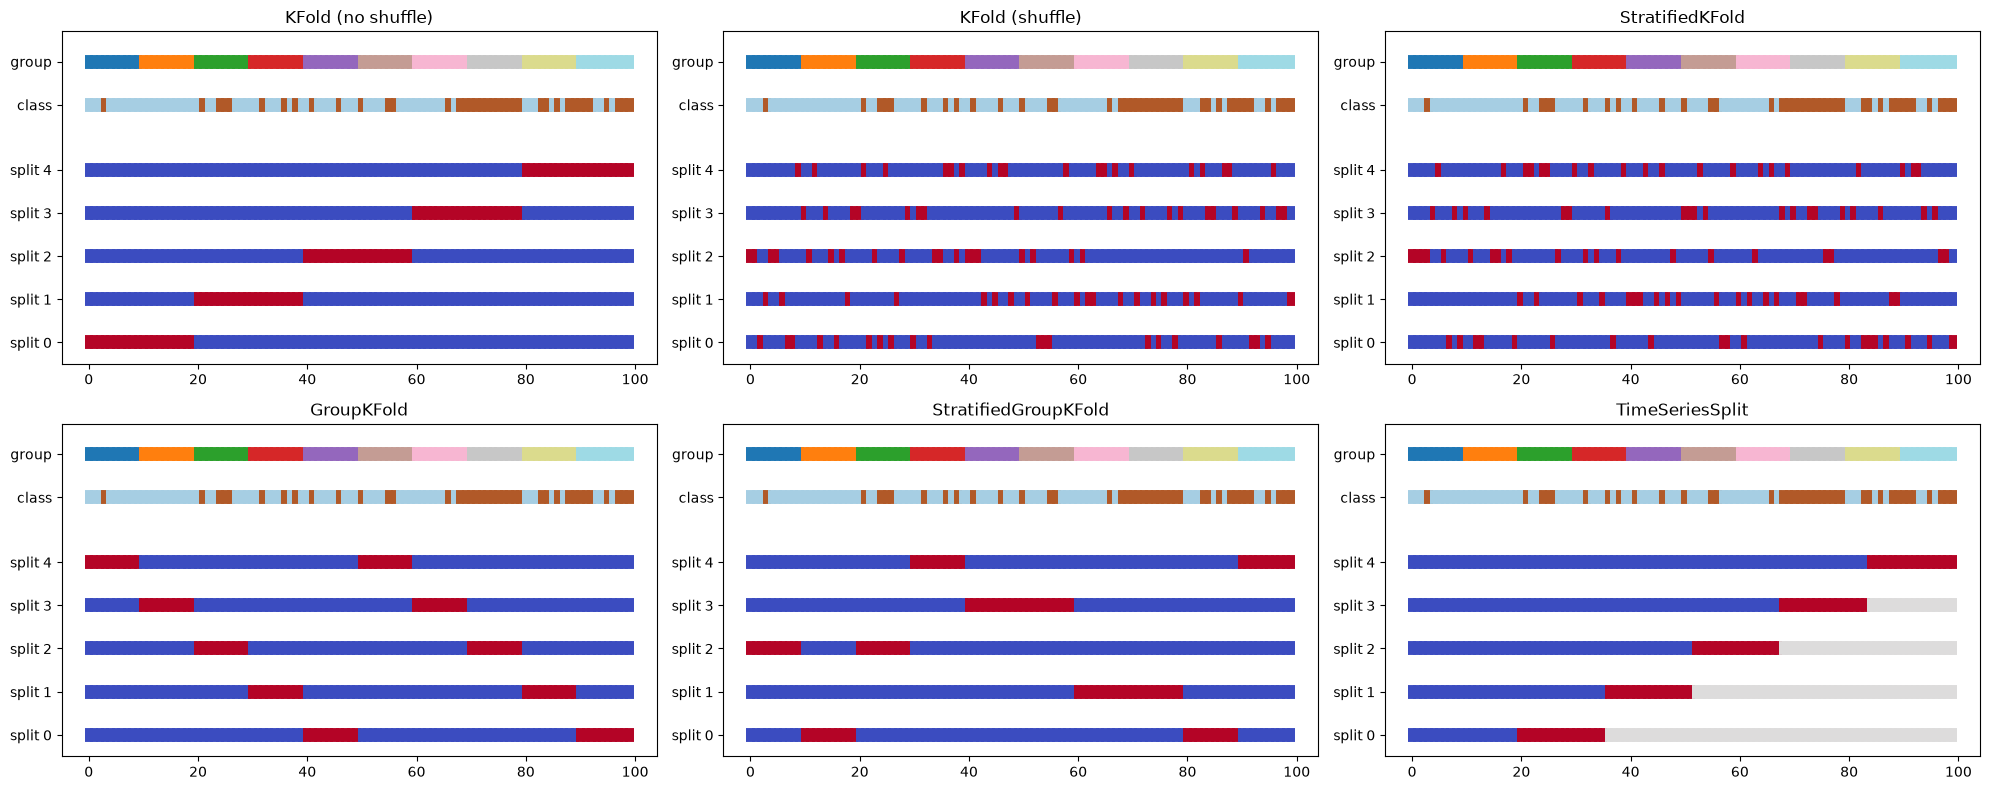

In [2]:
import warnings
warnings.filterwarnings("ignore", message="The groups parameter is ignored")   # non-group splitters simply ignore groups

def plot_cv(cv, X, y, groups, ax, title):
    for i, (tr, te) in enumerate(cv.split(X, y, groups)):
        idx = np.zeros(len(X)); idx[te] = 1; idx[np.setdiff1d(np.arange(len(X)), np.r_[tr, te])] = 0.5
        ax.scatter(range(len(X)), [i] * len(X), c=idx, marker="_", lw=10, cmap="coolwarm", vmin=0, vmax=1)
    ax.scatter(range(len(X)), [i + 1.5] * len(X), c=y, marker="_", lw=10, cmap="Paired")
    ax.scatter(range(len(X)), [i + 2.5] * len(X), c=groups, marker="_", lw=10, cmap="tab20")
    ax.set(yticks=list(range(i + 1)) + [i + 1.5, i + 2.5], yticklabels=[f"split {k}" for k in range(i + 1)] + ["class", "group"], title=title, ylim=[-0.5, i + 3.2])

n = 100
Xd = rng.normal(size=(n, 3)); yd = (rng.random(n) < np.linspace(0.1, 0.5, n)).astype(int); gd = np.repeat(np.arange(10), 10)
fig, axes = plt.subplots(2, 3, figsize=(20, 8))
for ax, (name, cv) in zip(axes.ravel(), [("KFold (no shuffle)", KFold(5)), ("KFold (shuffle)", KFold(5, shuffle=True, random_state=0)),
                                          ("StratifiedKFold", StratifiedKFold(5, shuffle=True, random_state=0)), ("GroupKFold", GroupKFold(5)),
                                          ("StratifiedGroupKFold", StratifiedGroupKFold(5, shuffle=True, random_state=0)), ("TimeSeriesSplit", TimeSeriesSplit(5))]):
    plot_cv(cv, Xd, yd, gd, ax, name)
plt.tight_layout(); plt.show()

Red = test, blue = train (grey = unused). Notice: GroupKFold never splits a group; TimeSeriesSplit always trains on the past and tests on the future.

## **2. How Many Folds? Bias and Variance of the CV Estimate**
- Fewer folds (K = 2-3): training sets are much smaller than the full data -> **pessimistic bias**.
- LOO (K = n): almost unbiased, but **high variance** (training sets nearly identical) and expensive.
- K = 5 or 10 is the usual compromise. **Repeated** K-fold averages over several random partitions to reduce the variance caused by the particular split.

In [3]:
from sklearn.datasets import make_classification
Xp, yp = make_classification(20000, 20, n_informative=6, random_state=0)       # a large pool to measure the "true" accuracy
pool_X, pool_y = Xp[:19800], yp[:19800]
model = LogisticRegression(max_iter=2000)
results = []
for rep in range(30):
    idx = rng.choice(19800, 200, replace=False); Xs, ys = pool_X[idx], pool_y[idx]
    true_acc = model.fit(Xs, ys).score(pool_X, pool_y)                          # performance of the model trained on all 200
    for name, cv in [("2-fold", KFold(2, shuffle=True, random_state=rep)), ("5-fold", KFold(5, shuffle=True, random_state=rep)),
                     ("10-fold", KFold(10, shuffle=True, random_state=rep)), ("LOO", LeaveOneOut()),
                     ("5x10-fold repeated", RepeatedKFold(n_splits=10, n_repeats=5, random_state=rep))]:
        est = cross_val_score(model, Xs, ys, cv=cv).mean()
        results.append({"cv": name, "error_of_estimate": est - true_acc})
res = pd.DataFrame(results).groupby("cv").error_of_estimate.agg(bias="mean", sd="std")
res["RMSE"] = np.sqrt(res.bias ** 2 + res.sd ** 2)
res.round(4).sort_values("RMSE")

,bias,sd,RMSE
cv,,,
10-fold,-0.0001,0.0260,0.0260
5x10-fold repeated,-0.0014,0.0271,0.0272
LOO,-0.0004,0.0286,0.0286
5-fold,-0.0069,0.0281,0.0289
2-fold,-0.0174,0.0307,0.0353


## **3. Group K-Fold: Repeated Measurements**
Multiple samples from the same entity (patient, field, image tile, tree, site) are correlated. If the same entity appears in training and test folds, the model can "recognise" it. Use `GroupKFold` with the entity ID.

In [4]:
n_fields, px = 80, 25
field_signal = rng.normal(size=(n_fields, 6)); field_label = rng.integers(0, 4, n_fields)
class_means = rng.normal(0, 0.6, (4, 6))
Xg = np.repeat(field_signal * 0.8 + class_means[field_label], px, axis=0) + rng.normal(0, 0.3, (n_fields * px, 6))
yg = np.repeat(field_label, px); groups = np.repeat(np.arange(n_fields), px)
rf = RandomForestClassifier(300, n_jobs=-1, random_state=0)
print(f"random KFold (pixels of one field in train AND test): {cross_val_score(rf, Xg, yg, cv=KFold(5, shuffle=True, random_state=0)).mean():.3f}")
print(f"GroupKFold   (whole fields held out)                 : {cross_val_score(rf, Xg, yg, cv=GroupKFold(5), groups=groups).mean():.3f}")

random KFold (pixels of one field in train AND test): 0.920


GroupKFold   (whole fields held out)                 : 0.525


The random split reports near-perfect accuracy, which is pure **field memorisation**. Group CV gives the honest answer for "how well will the model classify a **new field**?"

## **4. Time-Series Split**
For forecasting, the model must never be trained on data that comes **after** the test period.

In [5]:
t = np.arange(600)
series = 10 + 0.02 * t + 2 * np.sin(2 * np.pi * t / 50) + rng.normal(0, 0.7, 600)
lags = pd.DataFrame({f"lag{k}": pd.Series(series).shift(k) for k in [1, 2, 3, 7, 14]}).assign(t=t)
data = lags.assign(y=series).dropna()
Xt, yt = data.drop(columns="y").values, data.y.values
rfr = RandomForestRegressor(300, n_jobs=-1, random_state=0)
print(f"shuffled KFold R2: {cross_val_score(rfr, Xt, yt, cv=KFold(5, shuffle=True, random_state=0)).mean():.3f}  (leaks the future)")
print(f"TimeSeriesSplit R2: {cross_val_score(rfr, Xt, yt, cv=TimeSeriesSplit(5)).mean():.3f}  (honest: trees cannot extrapolate the trend)")
print(f"TimeSeriesSplit with a 14-step gap: {cross_val_score(rfr, Xt, yt, cv=TimeSeriesSplit(5, gap=14)).mean():.3f}")

shuffled KFold R2: 0.937  (leaks the future)


TimeSeriesSplit R2: 0.351  (honest: trees cannot extrapolate the trend)


TimeSeriesSplit with a 14-step gap: 0.172


`gap` leaves a buffer between training and test periods so lagged features do not leak information across the boundary.

## **5. Spatial Block CV (Preview)**
Pixels close in space are similar (spatial autocorrelation). Random CV puts neighbours in train and test; the model interpolates instead of generalising. Assign pixels to **spatial blocks** and use the block ID as the group.

In [6]:
nx = 60
xx, yy = np.meshgrid(np.arange(nx), np.arange(nx)); xx, yy = xx.ravel(), yy.ravel()
from scipy.ndimage import gaussian_filter
smooth = lambda s: gaussian_filter(rng.normal(size=(nx, nx)), s).ravel()
F = np.column_stack([smooth(4) for _ in range(5)]); F = (F - F.mean(0)) / F.std(0)
target = F[:, 0] * 2 + smooth(6) * 25 + rng.normal(0, 0.3, nx * nx)        # unmeasured spatial process too
blocks = (xx // 15) * 4 + (yy // 15)                                     # 16 blocks of 15 x 15 pixels
Fx = np.c_[F, xx, yy]
print(f"random KFold R2      : {cross_val_score(RandomForestRegressor(200, n_jobs=-1, random_state=0), Fx, target, cv=KFold(5, shuffle=True, random_state=0)).mean():.3f}")
print(f"spatial block CV R2  : {cross_val_score(RandomForestRegressor(200, n_jobs=-1, random_state=0), Fx, target, cv=GroupKFold(4), groups=blocks).mean():.3f}")

random KFold R2      : 0.980


spatial block CV R2  : 0.732


## **6. Nested Cross-Validation**
If we tune hyperparameters with CV and report the **same** CV score, the score is optimistically biased (we picked the best of many noisy estimates). **Nested CV**: an inner loop tunes, an outer loop evaluates the whole tuning procedure.

In [7]:
Xn, yn = make_classification(300, 50, n_informative=5, flip_y=0.1, random_state=1)
from sklearn.svm import SVC
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
param_grid = {"svc__C": np.logspace(-2, 3, 8), "svc__gamma": np.logspace(-4, 0, 8)}
pipe = make_pipeline(StandardScaler(), SVC())
non_nested, nested = [], []
for seed in range(8):
    inner = KFold(5, shuffle=True, random_state=seed); outer = KFold(5, shuffle=True, random_state=seed + 100)
    gs = GridSearchCV(pipe, param_grid, cv=inner).fit(Xn, yn)
    non_nested.append(gs.best_score_)
    nested.append(cross_val_score(GridSearchCV(pipe, param_grid, cv=inner), Xn, yn, cv=outer).mean())
print(f"non-nested (best CV score of the grid): {np.mean(non_nested):.3f}")
print(f"nested CV (honest)                    : {np.mean(nested):.3f}")
print(f"optimistic bias                       : {np.mean(non_nested) - np.mean(nested):+.3f}")

non-nested (best CV score of the grid): 0.715
nested CV (honest)                    : 0.690
optimistic bias                       : +0.026


# **Part 2: Going Deeper**

### Which CV for which data?

| Data structure | Use | Question answered |
|---|---|---|
| i.i.d. samples, classification | `StratifiedKFold` (repeated) | New sample from same population |
| Repeated measures (patients, fields, images) | `GroupKFold` / `StratifiedGroupKFold` | New entity |
| Time series | `TimeSeriesSplit` (with gap), rolling-origin | Future time period |
| Spatial data | Spatial block / buffered LOO / k-means clusters as groups | New location / region |
| Space + time | Leave-location-and-time-out | New place AND new time |
| Hyperparameter tuning + evaluation | Nested CV | Performance of the whole pipeline |

### The variance of CV is underestimated
The K fold scores are **not independent** (training sets overlap by $(K-2)/(K-1)$). The naive standard error $s/\sqrt{K}$ is too small, and paired t-tests on fold scores have inflated type-I errors. Bengio & Grandvalet (2004) proved there is no unbiased estimator of the CV variance. Nadeau & Bengio's **corrected resampled t-test** (Day 42) inflates the variance by $(1/k + n_{test}/n_{train})$.

## **Practice Problems**
1. For the field data, compare `GroupKFold`, `StratifiedGroupKFold` and `LeaveOneGroupOut` (80 groups). Which is most stable?
2. Implement a **rolling-origin** (expanding window) forecast evaluation manually for the time series with 1-step-ahead predictions over the last 100 points.
3. In the spatial example, use k-means on the coordinates (16 clusters) as groups instead of square blocks.
4. *(Advanced)* Show that the standard deviation of 10-fold CV scores divided by sqrt(10) underestimates the true variability of the CV mean across different datasets drawn from the pool.

In [8]:
# Solution 1
from sklearn.model_selection import LeaveOneGroupOut
for name, cv in [("GroupKFold(5)", GroupKFold(5)), ("StratifiedGroupKFold(5)", StratifiedGroupKFold(5, shuffle=True, random_state=0)), ("LeaveOneGroupOut", LeaveOneGroupOut())]:
    s = cross_val_score(RandomForestClassifier(100, n_jobs=-1, random_state=0), Xg, yg, cv=cv, groups=groups)
    print(f"{name:<24} mean {s.mean():.3f} sd over folds {s.std():.3f}")
# Solution 2: expanding window, refit before each 1-step-ahead forecast (every 10th step to save time)
abs_errors = []
for i in range(len(yt) - 100, len(yt), 10):
    m = RandomForestRegressor(100, n_jobs=-1, random_state=0).fit(Xt[:i], yt[:i])     # train on everything before time i
    abs_errors.append(abs(m.predict(Xt[i:i + 1])[0] - yt[i]))
print(f"rolling-origin MAE over {len(abs_errors)} forecast origins: {np.mean(abs_errors):.3f}")
# Solution 3
from sklearn.cluster import KMeans
km_groups = KMeans(16, n_init=10, random_state=0).fit_predict(np.c_[xx, yy])
print(f"k-means spatial CV R2: {cross_val_score(RandomForestRegressor(200, n_jobs=-1, random_state=0), Fx, target, cv=GroupKFold(4), groups=km_groups).mean():.3f}")
# Solution 4
means, naive_se = [], []
for rep in range(40):
    idx = rng.choice(19800, 200, replace=False)
    s = cross_val_score(model, pool_X[idx], pool_y[idx], cv=KFold(10, shuffle=True, random_state=rep))
    means.append(s.mean()); naive_se.append(s.std(ddof=1) / np.sqrt(10))
print(f"true SD of the CV mean across datasets: {np.std(means):.4f} | average naive SE: {np.mean(naive_se):.4f}")

GroupKFold(5)            mean 0.528 sd over folds 0.089


StratifiedGroupKFold(5)  mean 0.538 sd over folds 0.047


LeaveOneGroupOut         mean 0.528 sd over folds 0.400


rolling-origin MAE over 10 forecast origins: 0.702


k-means spatial CV R2: 0.683


true SD of the CV mean across datasets: 0.0249 | average naive SE: 0.0227


## **Key References**
- Kohavi, R. (1995). A study of cross-validation and bootstrap for accuracy estimation and model selection. *IJCAI 1995*, 1137-1145.
- Varma, S., & Simon, R. (2006). Bias in error estimation when using cross-validation for model selection. *BMC Bioinformatics*, 7, 91.
- Bengio, Y., & Grandvalet, Y. (2004). No unbiased estimator of the variance of K-fold cross-validation. *JMLR*, 5, 1089-1105.
- Roberts, D. R. et al. (2017). Cross-validation strategies for data with temporal, spatial, hierarchical, or phylogenetic structure. *Ecography*, 40(8), 913-929.
- Bergmeir, C., & Benitez, J. M. (2012). On the use of cross-validation for time series predictor evaluation. *Information Sciences*, 191, 192-213.
- Cawley, G. C., & Talbot, N. L. C. (2010). On over-fitting in model selection and subsequent selection bias in performance evaluation. *JMLR*, 11, 2079-2107.